In [1]:
import sys
import re

from pathlib import Path

import geopandas as gpd
from sqlalchemy import create_engine
from pyproj import CRS
import shapely.wkb as wkb
from shapely.geometry import box
from typing import Optional
from merge_layers import main as merge_layers
from spatial_data_pipe import SpatialDataProcessor, ProcessingConfig, DatabaseConfig

# Your specific processing configuration
config = ProcessingConfig(
    target_crs=4326,  # WGS84 (same as before)
    bbox_filter=(-116.688, 32.64, -114.472, 34.034),  # Salton Trough bounds
    state_filter="CALIFORNIA",  # Filter to California only
    county_filter={"IMPERIAL", "RIVERSIDE", "SAN DIEGO"},  # Your specific counties
    preferred_layers=["California (CA)", "California"],  # For KMZ files
    verbose=True,  # Enable detailed logging
    drop_z_dimension=True  # Standardize to 2D geometries
)

# Your database configuration
db_config = DatabaseConfig(
    host="localhost",
    port=5432,
    user="postgres",
    password="1123",
    database="lithiumvalley",  # Your specific database
    schema="public",
    geom_column="geom"
)

# Create processor with your settings
processor = SpatialDataProcessor(
    config=config,
    output_dir="data/processed/surface",  # Your output directory
    #db_config=db_config
)
paths = paths = [
    r"../../data/Surface/BLM_CA_GEOTHERMAL_LEASES/BLM_CA_Geothermal_Leases_Polygon.shp",
    r"../../data/Surface/BLM_Natl_Rights_of_Way_Planning_Tool_Energy_Designations_Group_Feature_Layer/BLM_DRECP_Development_Focus_Area_(DFA).shp",
    r"../../data/Surface/BLM_Natl_Rights_of_Way_Planning_Tool_Energy_Designations_Group_Feature_Layer/BLM_DRECP_Variance_Land.shp",
    r"../../data/Surface/CalGem_Geothermal_Wells/CalGEM%3A_Geothermal_Wells.shp",  # Fixed: %3A instead of :
    r"../../data/Surface/Federal_American_Indian_Reservations/Federal_American_Indian_Reservations.shp",
    r"../../data/Surface/surface_agency/SurfaceManagementAgency_SaltonTrough.shp",  # Fixed: correct filename
    r"../../data/SubSurface/GEOTHERM/GEOTHERM_ALL(GEO_ALL).csv"
]
gdfs = {}
for path in paths:
    gdf = processor.process_file(path)
    gdfs[Path(path).name.split('.')[0]] = (gdf)

print('success, last gdf\n',gdf.head())






Processing shapefile: ..\..\data\Surface\BLM_CA_GEOTHERMAL_LEASES\BLM_CA_Geothermal_Leases_Polygon.shp
Reading shapefile: ..\..\data\Surface\BLM_CA_GEOTHERMAL_LEASES\BLM_CA_Geothermal_Leases_Polygon.shp
Loaded 101 features
Detected CRS: EPSG:3310
After bbox filtering: 33 features
Returning gdf with 33 features
Processing shapefile: ..\..\data\Surface\BLM_Natl_Rights_of_Way_Planning_Tool_Energy_Designations_Group_Feature_Layer\BLM_DRECP_Development_Focus_Area_(DFA).shp
Reading shapefile: ..\..\data\Surface\BLM_Natl_Rights_of_Way_Planning_Tool_Energy_Designations_Group_Feature_Layer\BLM_DRECP_Development_Focus_Area_(DFA).shp
Loaded 171 features
Detected CRS: EPSG:3857
After bbox filtering: 121 features
Returning gdf with 121 features
Processing shapefile: ..\..\data\Surface\BLM_Natl_Rights_of_Way_Planning_Tool_Energy_Designations_Group_Feature_Layer\BLM_DRECP_Variance_Land.shp
Reading shapefile: ..\..\data\Surface\BLM_Natl_Rights_of_Way_Planning_Tool_Energy_Designations_Group_Feature_Lay

In [2]:
gdfs.keys()

dict_keys(['BLM_CA_Geothermal_Leases_Polygon', 'BLM_DRECP_Development_Focus_Area_(DFA)', 'BLM_DRECP_Variance_Land', 'CalGEM%3A_Geothermal_Wells', 'Federal_American_Indian_Reservations', 'SurfaceManagementAgency_SaltonTrough', 'GEOTHERM_ALL(GEO_ALL)'])

In [14]:
# Prepare BLM data (gdfs[-1]) - keep necessary columns and ensure unique ID
surface_gdf = gdfs['SurfaceManagementAgency_SaltonTrough']
# Add a unique ID column if SMA_ID is not unique
if not surface_gdf['SMA_ID'].is_unique:
    surface_gdf = surface_gdf.reset_index(drop=True)
    surface_gdf['unique_id'] = surface_gdf.index + 1
    blm_id_col = 'unique_id'
else:
    blm_id_col = 'SMA_ID'

# Prepare reservation data (gdfs[-2])
res_gdf = gdfs['Federal_American_Indian_Reservations']
res_gdf.head()
test = gpd.sjoin(surface_gdf,res_gdf,how='left',predicate='intersects')

res_gdf.to_file("'Federal_American_Indian_Reservations'.shp")
test.to_file("test.shp")


C:\Users\ratth\AppData\Local\Temp\ipykernel_3440\2409995625.py:17: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  test.to_file("test.shp")
c:\Users\ratth\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(


In [4]:
surface_gdf.head()
# Call merge_layers with proper column mapping

result_gdf = merge_layers(
    main_gdf=surface_gdf,
    merge_gdf=res_gdf,
    main_id_col='unique_id',
    main_admin_col='ADMIN_AGEN',
    main_geom_col='geometry',
    merge_name_col='NAME',
    merge_geom_col='geometry',
)



<Axes: >

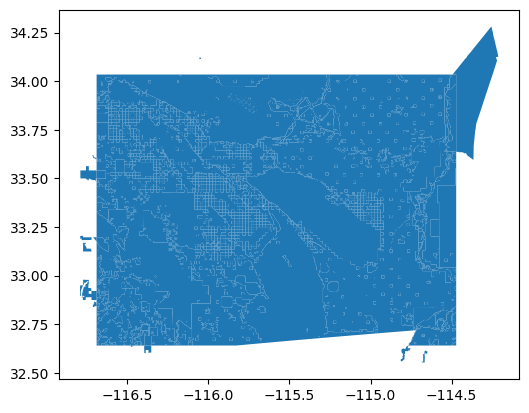

In [8]:
result_gdf.plot()


<Axes: >

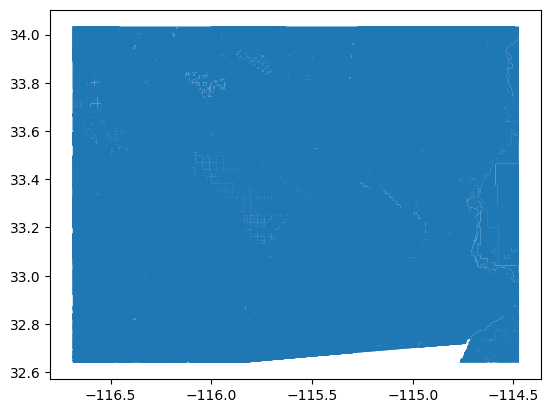

In [12]:
test.plot()

In [ ]:
test == result_gdf

In [ ]:
import matplotlib.pyplot as plt


# Simple plot of merged results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Original BLM vs Reservations
ax1.set_title('Original Data')
surface_gdf.plot(ax=ax1, color='blue', alpha=0.7, label='BLM Areas')
res_gdf.plot(ax=ax1, color='red', alpha=0.7, label='Reservations')
ax1.legend()

# Plot 2: Merged results
ax2.set_title('Merged Results')
result_gdf.plot(column='geom_type', ax=ax2, legend=True, alpha=0.8)

plt.tight_layout()
plt.show()

# Simple summary
print(f"Total geometries: {len(result_gdf)}")
print(result_gdf['geom_type'].value_counts())

In [ ]:

result_gdf.rename(columns={'merge_name':'reservation_name'},inplace=True)
result_gdf.columns


In [ ]:
leases = gdfs['BLM_CA_Geothermal_Leases_Polygon']

print(len(leases['serial_nr_']),leases.shape)

In [ ]:
leases.columns

In [ ]:


# Simple plot of merged results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Original BLM vs Reservations
ax1.set_title('Original Data')
surface_gdf.plot(ax=ax1, color='blue', alpha=0.7, label='BLM Areas')
result_gdf.plot(ax=ax1, color='red', alpha=0.7, label='Reservations')
ax1.legend()

result_gdf = merge_layers(
    result_gdf,leases,'id','main_admin','geometry','serial_nr_','geometry',preserve_columns={
        'main':result_gdf.columns.tolist(),
        'merge':['last_edite','casetype_t','casetype']
        })

# Plot 2: Merged results
ax2.set_title('Merged Results')
result_gdf.plot(column='geom_type', ax=ax2, legend=True, alpha=0.8)

plt.tight_layout()
plt.show()

# Simple summary
print(f"Total geometries: {len(result_gdf)}")
print(result_gdf['geom_type'].value_counts())

(['', 'BLM_DRECP_Development_Focus_Area_(DFA)', 'BLM_DRECP_Variance_Land', 'CalGEM%3A_Geothermal_Wells', '', ''])


In [ ]:
result_gdf.rename(columns={'merge_name':'geothermal_leases_ID'},inplace=True)
result_gdf.head()

result_gdf.to_file("result_gdf.shp")



In [ ]:
result_gdf.columns


hierarcy = 'geothermal_leases_ID','reservation_name', 'main_admin'


In [ ]:
dev_gdf = gdfs['BLM_DRECP_Development_Focus_Area_(DFA)']
good_cols = ['technology','geom']
dev_gdf = dev_gdf.reset_index(drop=True)
dev_gdf['unique_id'] = dev_gdf.index + 1
result_gdf = merge_layers(
    main_gdf=result_gdf,
    merge_gdf=dev_gdf,
    main_id_col='main_id',           # Use 'id' as the main ID column
    main_admin_col='main_admin',
    main_geom_col='geometry',   # This should be 'geometry', not 'main_id'
    merge_name_col='unique_id',
    merge_geom_col='geometry',
    preserve_columns={
        'main': result_gdf.columns.tolist(),
        'merge': ['technology']
    }
)
result_gdf.head()




In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Original BLM vs Reservations
ax1.set_title('Original Data')
dev_gdf.plot(ax=ax1, color='blue', alpha=0.7, label='original')
result_gdf.plot(ax=ax1, color='red', alpha=0.7, label='merger')
ax1.legend()

ax2.set_title('Merged Results')
result_gdf.plot(column='geom_type', ax=ax2, legend=True, alpha=0.8)

plt.tight_layout()
plt.show()

In [ ]:
result_gdf.drop(columns=['main_id','merge_name','geom_type'],inplace=True)

In [ ]:
result_gdf.to_file("result_gdf.shp")
